In [1]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [2]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c':
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v)
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="medMax")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
        means = np.mean(arr)
        inMean = 1 / means
        alpha = pow(np.mean(arr),2) / np.var(arr)
        beta = np.var(arr) / np.mean(arr)
        params = gamma.fit(arr)
        posNeg4 = []
        spaceStep4 = np.linspace(.9,.99,20)
        for e in spaceStep4:
            #newArr = arr > gamma.ppf(e,alpha,scale=beta)
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2])
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots


def outputResultsArt(X,y,lowerRange=2,upperRange=70,checkValue=1):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v)
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="medMax")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
        means = np.mean(arr)
        inMean = 1 / means
        alpha = pow(np.mean(arr),2) / np.var(arr)
        beta = np.var(arr) / np.mean(arr)
        params = gamma.fit(arr)
        posNeg4 = []
        spaceStep4 = np.linspace(.9,.99,20)
        for e in spaceStep4:
            #newArr = arr > gamma.ppf(e,alpha,scale=beta)
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2])
            posNeg4.append([((y[newArr] == checkValue).sum() / (y == checkValue).sum()), (y[newArr] != checkValue).sum()/ ((y != checkValue).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def goodnessOfFit(X,y,kValue):
    knn, distReturn = main(X, y, kValue) # return knn and distance
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax") #
    print(skew(arr)) # check for skewness
    params = gamma.fit(arr) # fit the arr generated and get the params
    test = np.linspace(min(arr),max(arr),10)
    # pdfTest = expon.pdf(test,params[0],params[1]) #line used to test the pdf form

    values, edges = np.histogram(arr, bins=int(np.sqrt(len(arr))), density=True) #get values from bins and the edges
    #print(values, edges)
    newX = edges[:-1] + np.diff(edges) # X values from the bins

    pdf_fitted = gamma.pdf(newX,params[0], loc=params[1], scale=params[2]) # generate a new pdf using the new X values
    residuals = values - pdf_fitted # values vs the generated pdf
    print(pdf_fitted)
    #print(np.dot(residuals, residuals))
    print(sum(pow(residuals, 2) / pdf_fitted)) # prints the chi squared value
    plt.scatter(edges[:-1], values)
    plt.scatter(edges[:-1], pdf_fitted)
    plt.show()

def ksTestArr(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = gamma.fit(arr)
    results = stats.ks_1samp(arr, gamma.cdf,args=(params[0],params[1],params[2]))
    print(f"stats: {results[0]}, p-value:{results[1]}")
    plt.hist(arr,bins=20)
    plt.title(name)
    plt.show()

def monteCarloTestArr(X,y,kValue):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = gamma.fit(arr)
    results = monte_carlo_test()


def ksTestNorm(X,y,kValue):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = stats.skewnorm.fit(arr)
    results = stats.kstest(arr, stats.skewnorm.cdf,args=(params[0],params[1],params[2]))
    print(f"stats: {results[0]}, p-value:{results[1]}")

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = gamma.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    results = probplot(arr,dist=stats.gamma, plot=plt,sparams=(params[0],params[1],params[2]))
    plt.title(name)
    plt.show()

0.9000000000000001 3 [0.8925000000000001, 0.9000000000000001, 0.8944444444444445, 0.8774509803921567, 0.8725490196078431, 0.777027027027027, 0.7638888888888888, 0.7638888888888888, 0.777027027027027, 0.7837837837837838, 0.736111111111111, 0.8055555555555556, 0.8142857142857143, 0.8285714285714285, 0.8235294117647058, 0.8285714285714285, 0.8124999999999999, 0.8285714285714285, 0.8308823529411764, 0.8285714285714285, 0.8357142857142857, 0.8194444444444444, 0.8428571428571429, 0.8428571428571429, 0.8472222222222222, 0.8402777777777778, 0.8541666666666666, 0.8888888888888888, 0.8888888888888888, 0.8819444444444444, 0.8819444444444444, 0.8819444444444444, 0.8819444444444444, 0.8999999999999999, 0.8999999999999999, 0.8819444444444444, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8928571428571428, 0.7714285714285714, 0.7714285714285714, 0.8428571428571427, 0.857142857142857, 0.8428571428571427, 0.8333333333333333, 0.8194444444444444, 0.8333333333333333, 0.8194444444444444, 0.

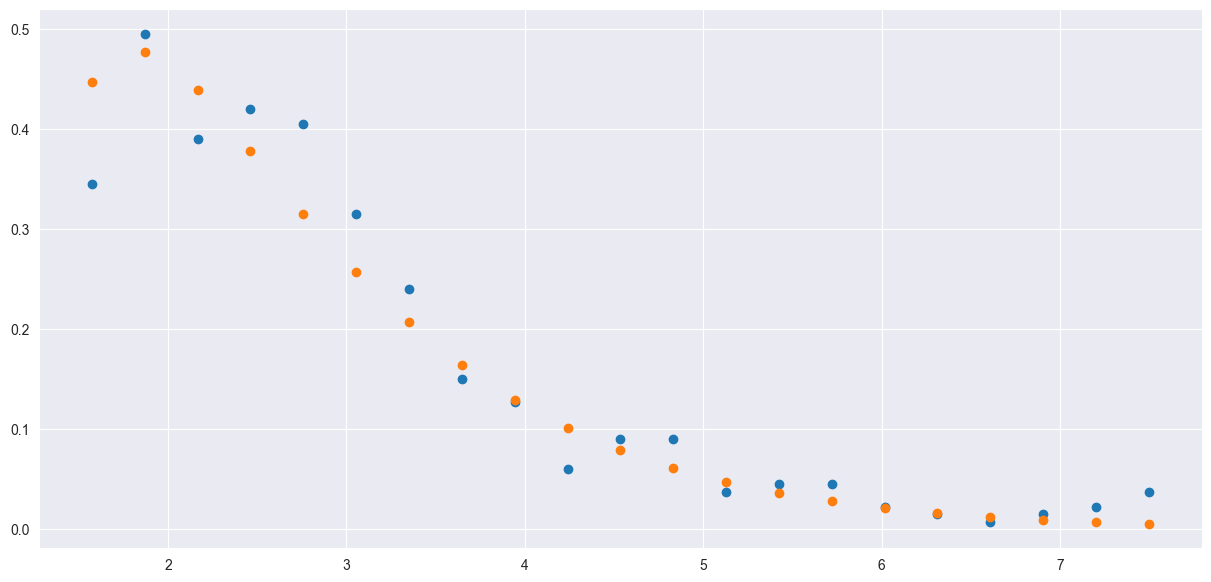

stats: 0.02638576246273061, p-value:0.904364104091474


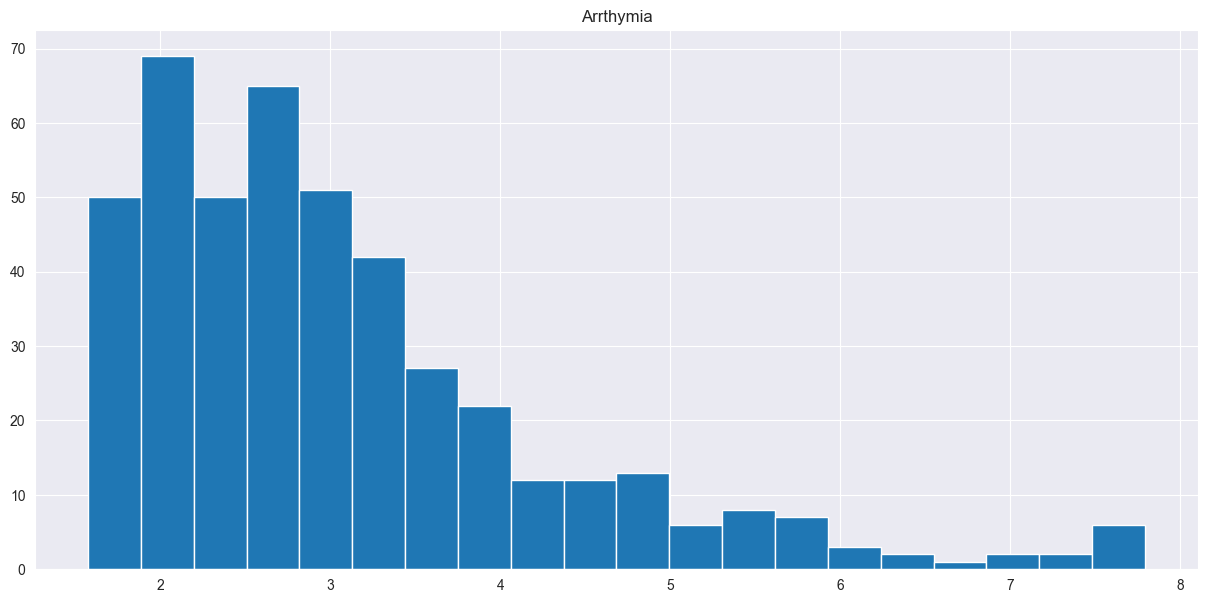

stats: 0.07792856573016538, p-value:0.00799324441918286
a: 1.5382700058131062 Loc: 1.568052843729826, Scale: 0.9825118907819039


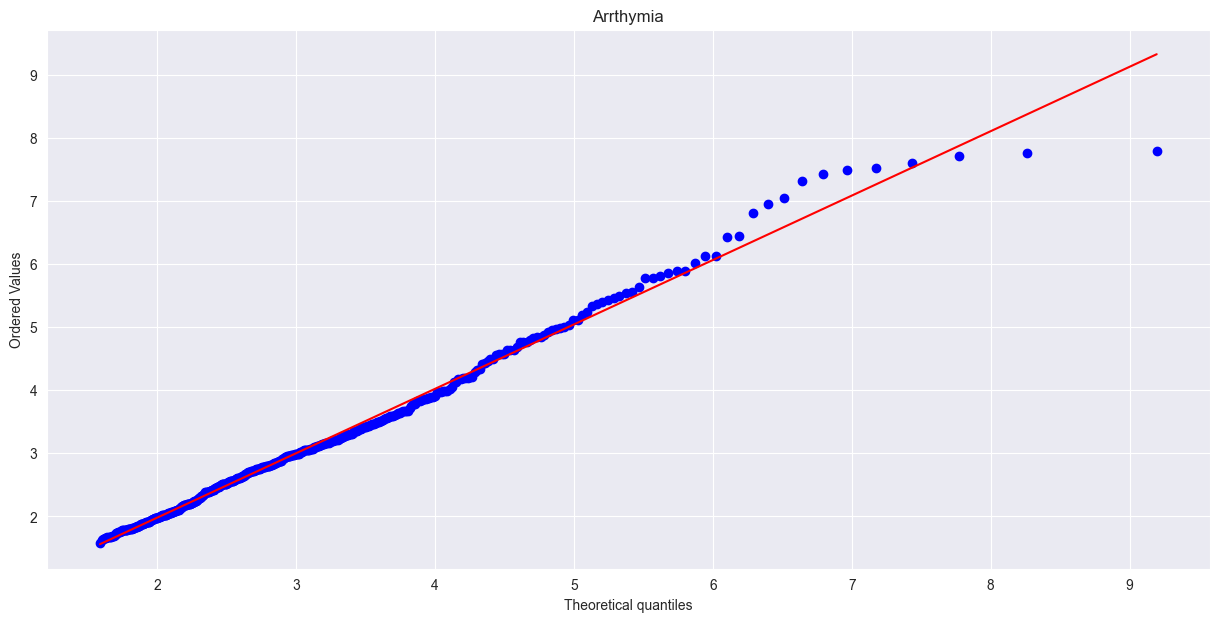

In [3]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,3)
ksTestArr(X,y,3,"Arrthymia")
ksTestNorm(X,y,3)
qqPlots(X,y,3,"Arrthymia")

1.0 3 [0.6666666666666667, 1.0, 1.0, 0.7727272727272727, 0.5000000000000001, 0.7272727272727272, 0.9, 0.925, 0.7727272727272727, 1.0, 0.8181818181818181, 0.7954545454545454, 0.8409090909090908, 1.0, 0.8181818181818181, 0.7954545454545454, 1.0, 0.75, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9615384615384615, 0.8555555555555554, 1.0, 0.9615384615384615, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8928571428571428, 0.9583333333333334, 0.923076923076923, 0.9583333333333334, 0.9583333333333334, 0.8846153846153846, 0.8461538461538461, 0.8333333333333333, 1.0, 1.0]
2.3642766368368147
[1.19267488e+00 1.56963544e+00 1.26968325e+00 8.19987954e-01
 4.64840067e-01 2.42003925e-01 1.18653147e-01 5.56380811e-02
 2.52062674e-02 1.11107590e-02 4.78942029e-03 2.02660988e-03
 8.44235629e-04]
10.531156327492681


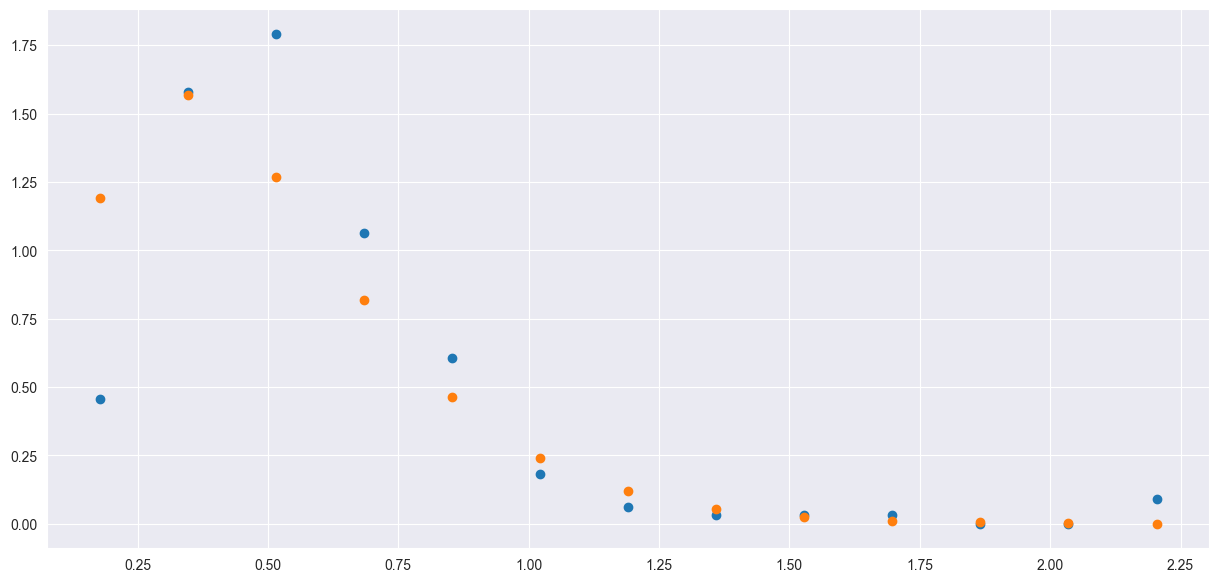

stats: 0.05763559653687711, p-value:0.5175916029817735


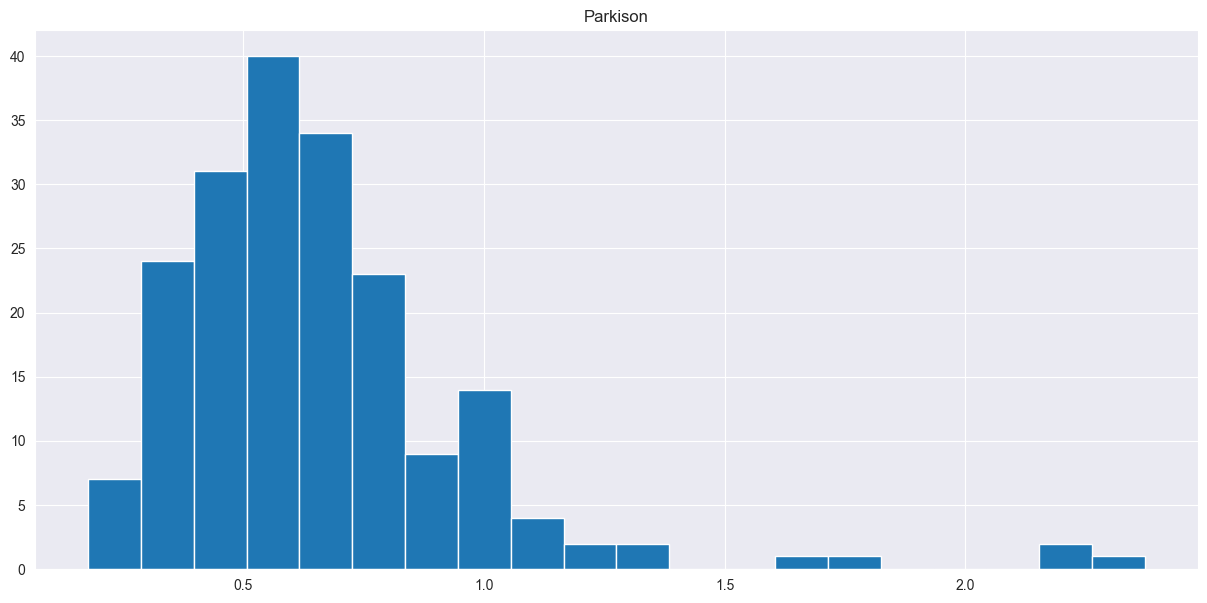

stats: 0.09296488650852297, p-value:0.06442871294037078
a: 3.36619499342042 Loc: 0.1235672534753686, Scale: 0.15925918276813048


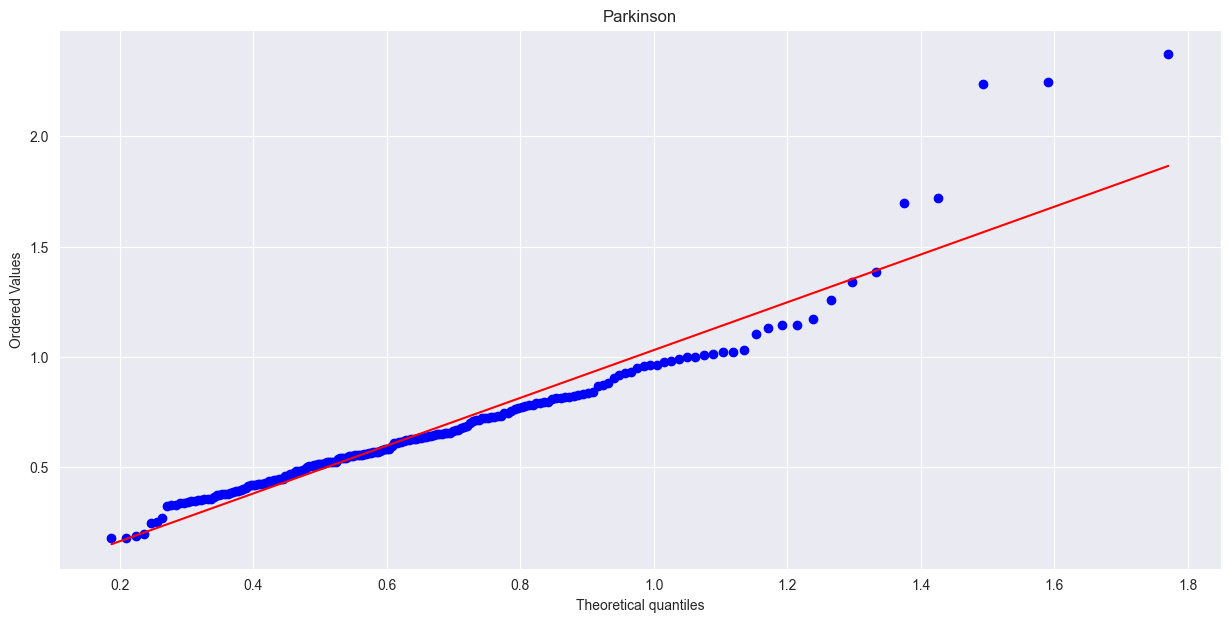

In [4]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,3)
ksTestArr(X,y,3,"Parkison")
ksTestNorm(X,y,3)
qqPlots(X,y,3,"Parkinson")

1.0 17 [0.9453125, 0.8287937743190662, 0.5483870967741935, 0.875, 0.0, 0.5093333333333333, 0.6286407766990292, 0.9527027027027026, 0.962962962962963, 0.8679245283018868, 0.0, 0.9512195121951219, 0.6395348837209301, 0.875, 0.4833333333333334, 1.0, 0.6354166666666667, 0.8301886792452831, 0.8125, 0.7583333333333333, 0.7155172413793103, 0.0, 0.6929824561403508, 0.7543859649122807, 0.8416666666666666, 0.7272727272727273, 0.8362068965517242, 0.7327586206896551, 0.7083333333333333, 0.7327586206896551, 0.7166666666666666, 0.7416666666666666, 0.8666666666666666, 0.864406779661017, 0.7678571428571429, 0.8333333333333334, 0.8303571428571428, 0.7380952380952381, 0.7580645161290323, 0.6929824561403508, 0.6639344262295082, 0.8333333333333333, 0.6724137931034482, 0.8679245283018867, 0.8679245283018868, 0.8727272727272727, 0.8534482758620688, 0.8333333333333333, 0.7903225806451613, 0.8688524590163935, 0.8688524590163935, 0.5714285714285714, 0.7868852459016393, 0.8064516129032258, 0.8852459016393442, 0

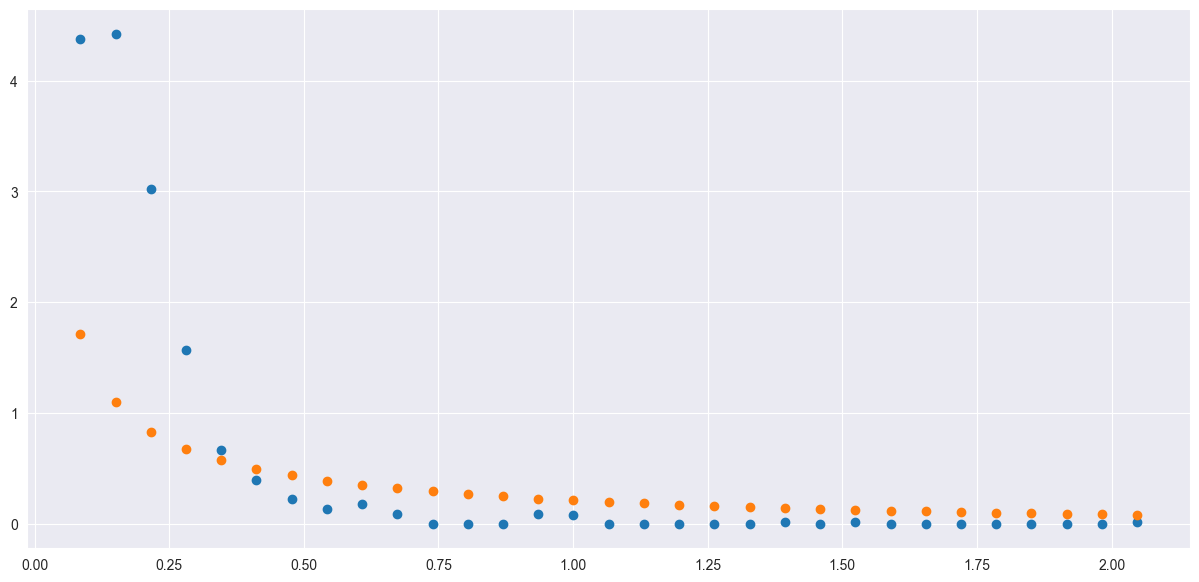

stats: 0.39437206685970083, p-value:1.5701975477935761e-142


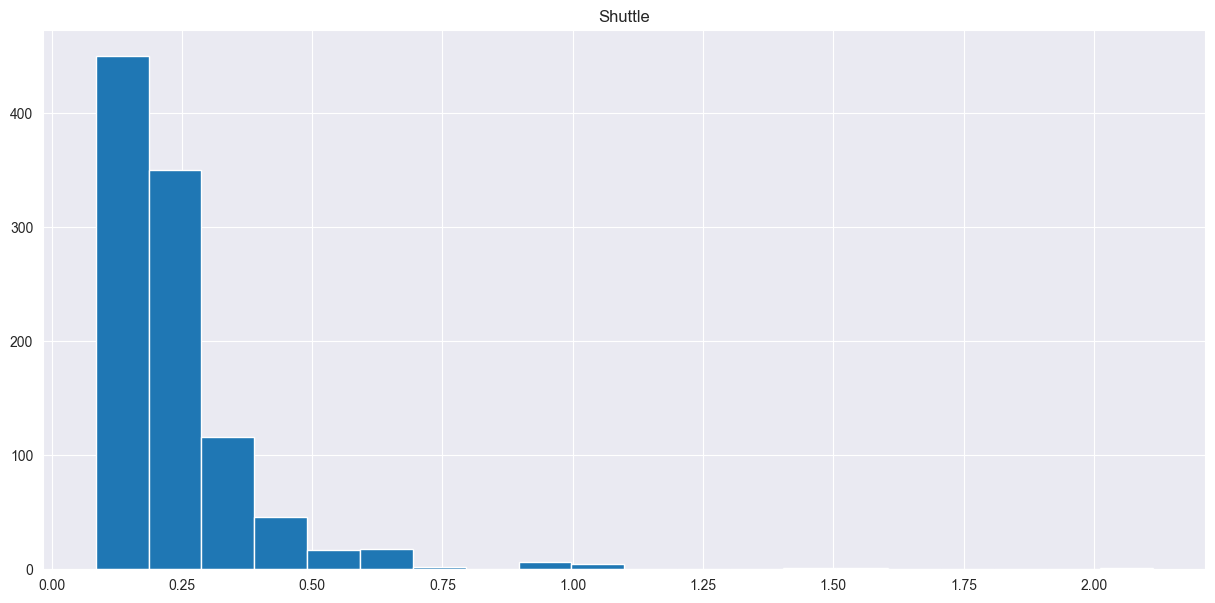

stats: 0.15817180229919714, p-value:1.3261590800858225e-22
a: 0.4011907429288323 Loc: 0.08492157392948778, Scale: 1.9358858523462503


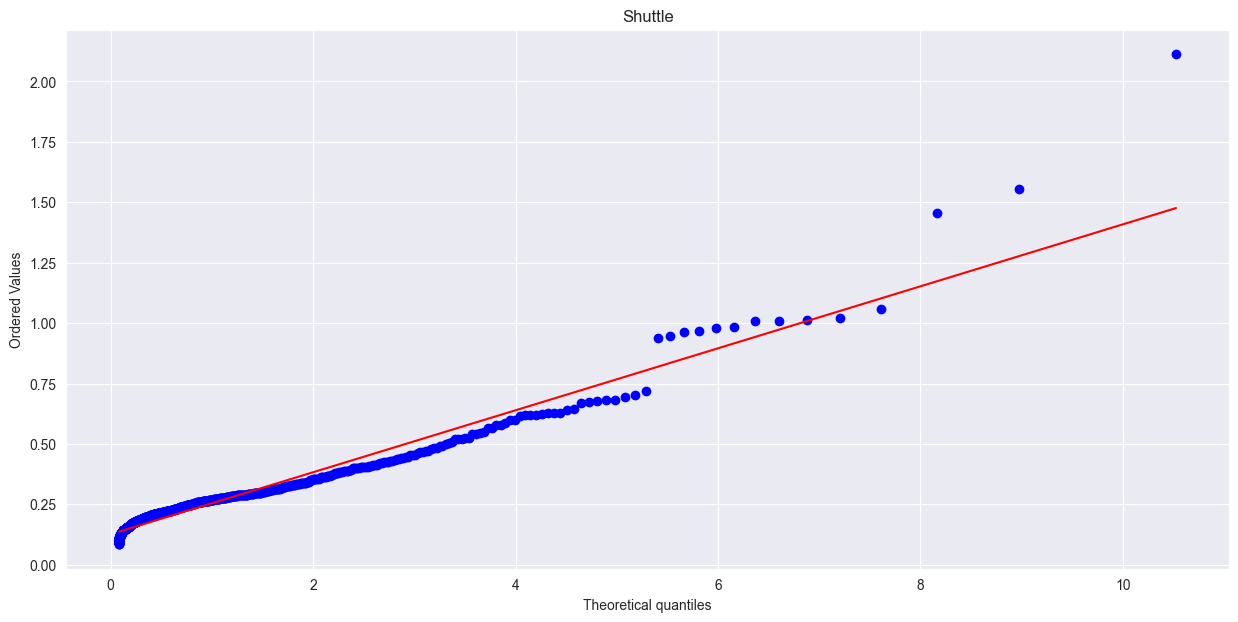

In [5]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,17)
ksTestArr(X,y,17,"Shuttle")
ksTestNorm(X,y,17)
qqPlots(X,y,17,"Shuttle")

0.9691358024691357 2 [0.9691358024691357, 0.6759259259259259, 0.805, 0.7944444444444444, 0.9074074074074073, 0.8596491228070176, 0.692982456140351, 0.6052631578947368, 0.8815789473684211, 0.8596491228070176, 0.7916666666666669, 0.7666666666666668, 0.7236842105263158, 0.8833333333333333, 0.9166666666666667, 0.9058823529411765, 0.8941176470588236, 0.8750000000000001, 0.7894736842105263, 0.8823529411764707, 0.9313725490196079, 0.921875, 0.9330357142857144, 0.9330357142857143, 0.9330357142857144, 0.926470588235294, 0.9313725490196079, 0.9322916666666667, 0.9419642857142858, 0.9362745098039216, 0.9428571428571428, 0.9322916666666667, 0.9464285714285716, 0.9427083333333335, 0.9464285714285714, 0.9476190476190478, 0.9411764705882353, 0.9333333333333333, 0.9428571428571431, 0.9428571428571431, 0.925, 0.8235294117647058, 0.9476190476190478, 0.9375, 0.823529411764706, 0.9476190476190478, 0.6666666666666666, 0.925, 0.9428571428571428, 0.9428571428571431, 0.6944444444444444, 0.9166666666666665, 0.

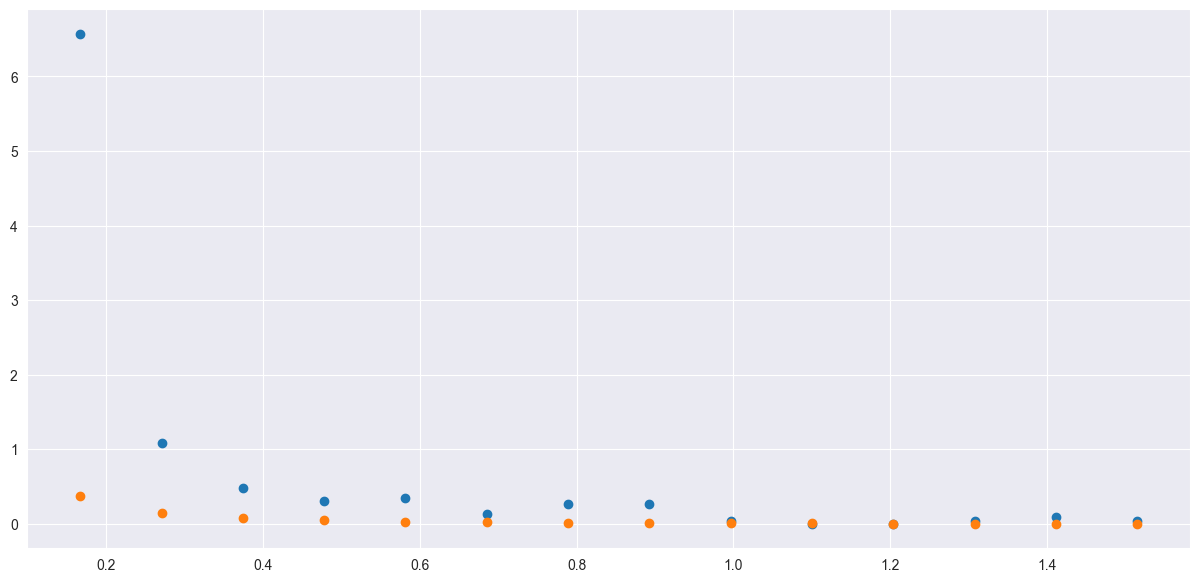

stats: 0.3920421184156341, p-value:2.156749049363568e-31


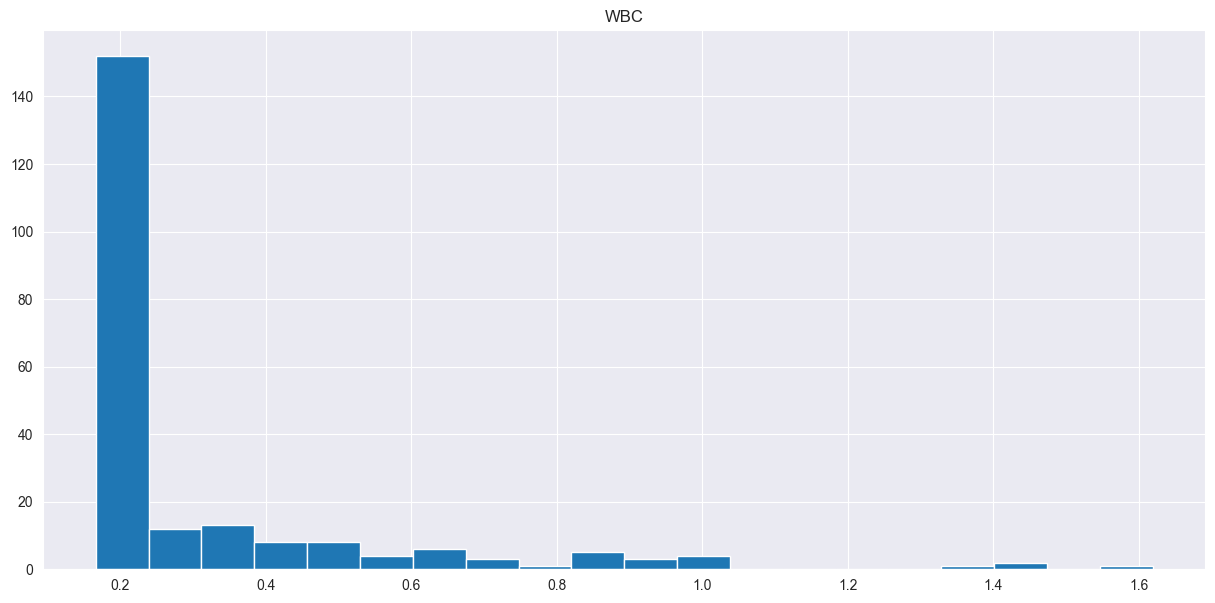

stats: 0.5246636771300448, p-value:1.0479947451756621e-57
a: 0.051014861227814554 Loc: 0.16666666666666663, Scale: 0.4196122953531984


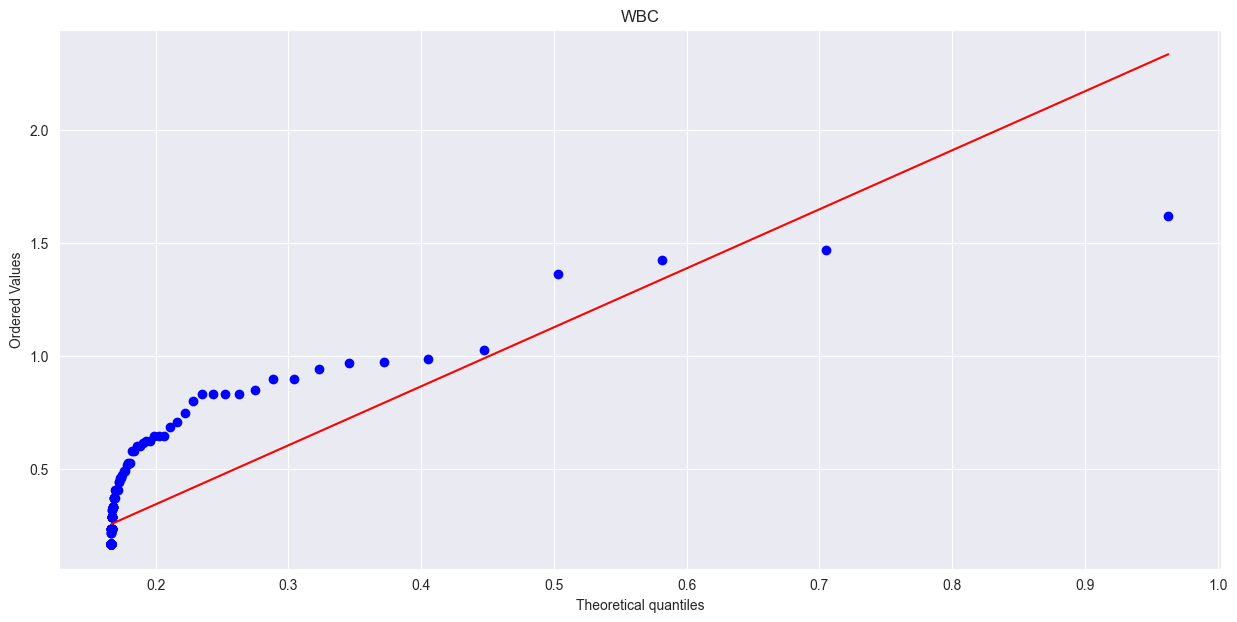

In [6]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)
ksTestArr(X,y,2,"WBC")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"WBC")

0.509064056527279 5 [0.4675094848878365, 0.46417281348788203, 0.48192697891987135, 0.509064056527279, 0.4643247510323051, 0.4595375722543353, 0.4525818954738685, 0.4319284414796847, 0.42315476190476203, 0.45074370709382156, 0.47640942420964066, 0.48212891211629727, 0.49350503919372907, 0.46691606266074354, 0.4499972389419626, 0.4439893862482694, 0.44972497249724974, 0.4614606741573034, 0.4720228718128245, 0.4626943005181347, 0.46281453867660766, 0.46323529411764697, 0.4704389826363415, 0.46222877865879897, 0.47947908445146004, 0.490381982475356, 0.48374178532311074, 0.4770114942528737, 0.4690992767915845, 0.4659339856871624, 0.470059880239521, 0.49922767995057155, 0.5033249882647474, 0.4944453137224223, 0.4792929292929293, 0.4613542835765058, 0.44466488709328333, 0.4730263157894736, 0.4803263302288643, 0.47507440476190477, 0.4690548780487805, 0.47067018072289163, 0.4752338196782642, 0.4940119760479041, 0.4978761198640718, 0.49401709401709404, 0.49532746370095776, 0.4891489033055299, 0.

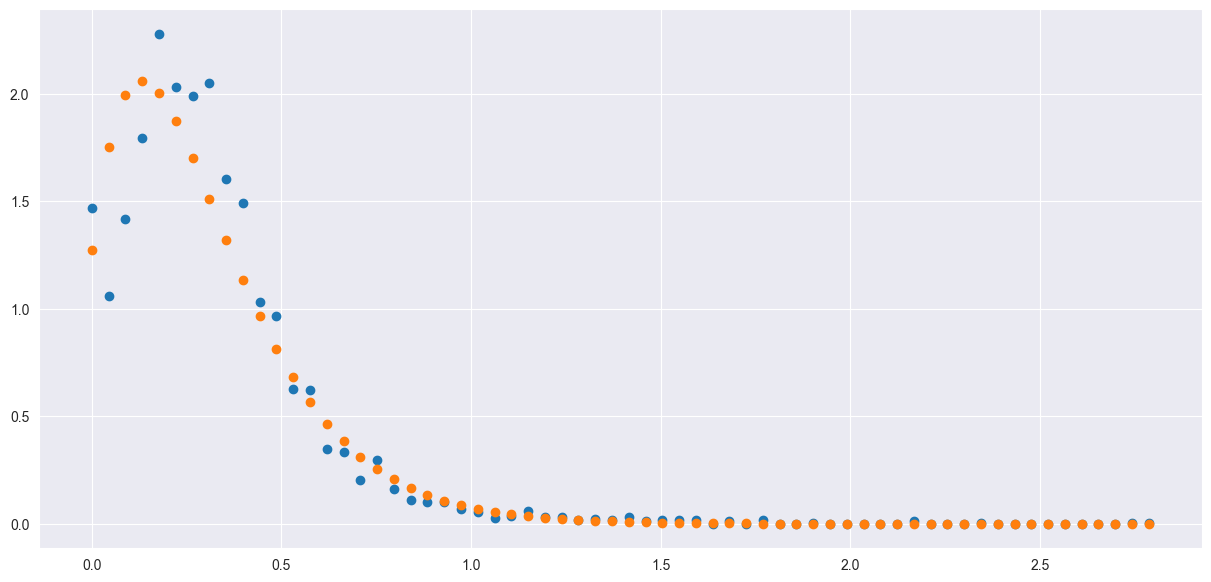

stats: 0.03869099100650819, p-value:6.577318780621224e-06


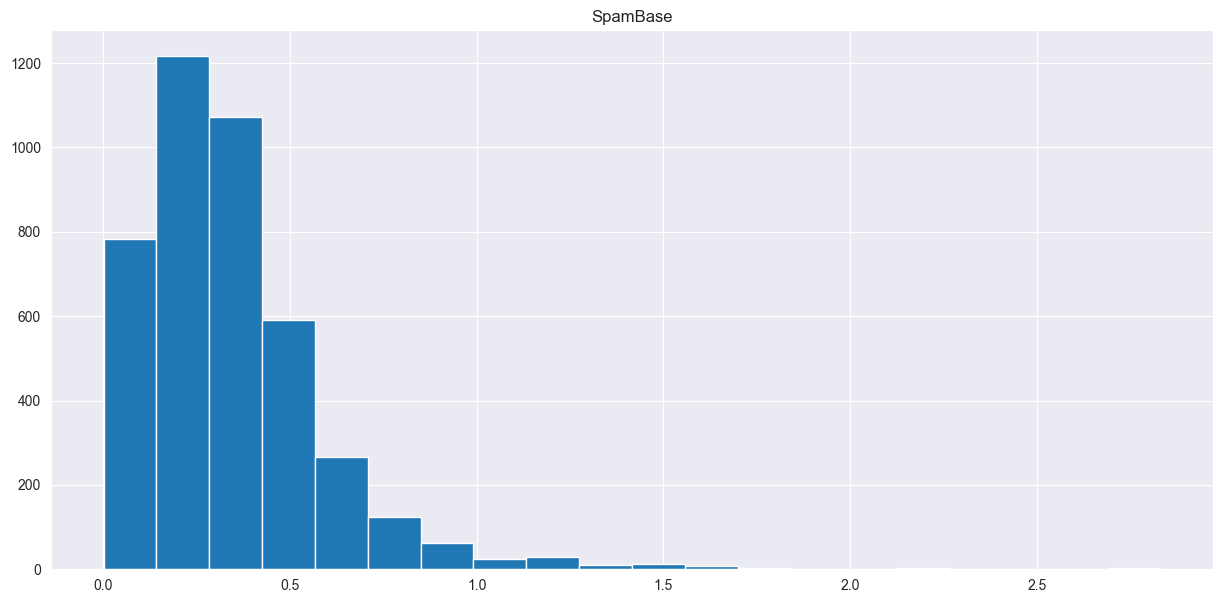

stats: 0.08032016639137576, p-value:4.687220908596632e-24
a: 2.303280878413119 Loc: -0.031748355234061276, Scale: 0.15936593665000526


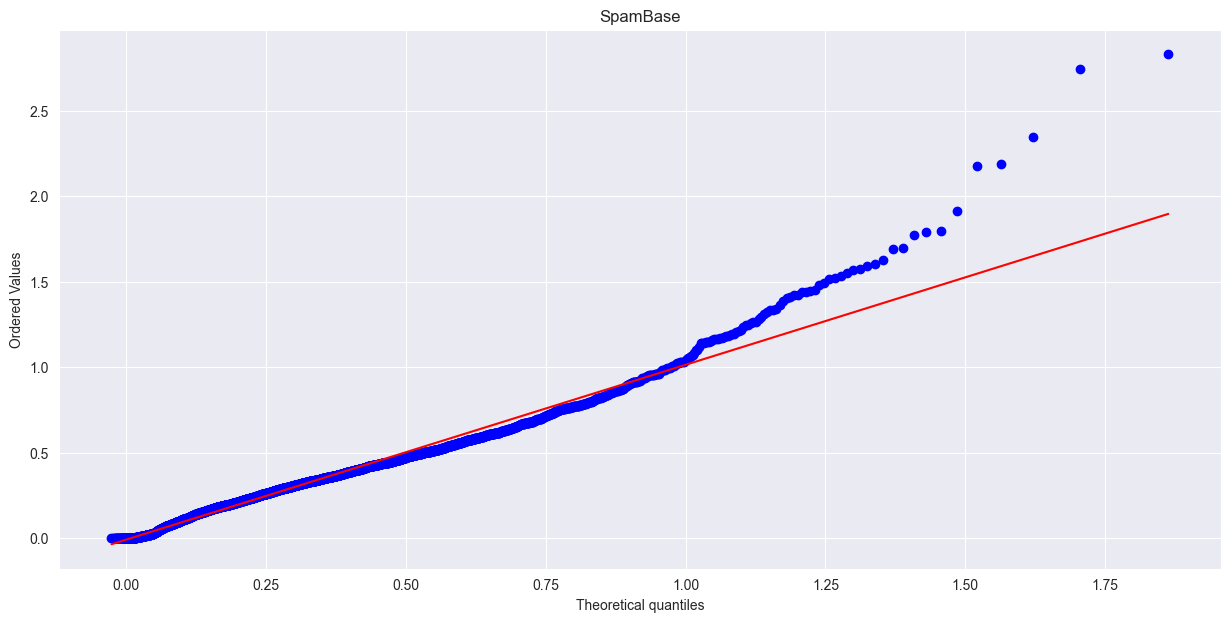

In [7]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,5)
ksTestArr(X,y,5,"SpamBase")
ksTestNorm(X,y,5)
qqPlots(X,y,5,"SpamBase")

0.8333333333333334 67 [0.75, 0.7500000000000001, 0.75, 0.5333333333333332, 0.511904761904762, 0.796875, 0.8055555555555556, 0.8125, 0.7916666666666665, 0.5196078431372549, 0.44852941176470595, 0.6764705882352942, 0.6862745098039216, 0.5588235294117647, 0.5882352941176471, 0.6328125, 0.6691176470588236, 0.6691176470588236, 0.6764705882352942, 0.6911764705882353, 0.6691176470588236, 0.6838235294117647, 0.6911764705882353, 0.6764705882352942, 0.7013888888888888, 0.7013888888888888, 0.6944444444444444, 0.75, 0.7222222222222221, 0.7152777777777777, 0.7361111111111112, 0.7430555555555555, 0.7569444444444444, 0.7708333333333333, 0.7569444444444444, 0.7569444444444444, 0.764705882352941, 0.7421875, 0.796875, 0.7999999999999998, 0.7916666666666665, 0.7833333333333332, 0.8046875, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7916666666666665, 0.7333333333333334, 0.7333333333333334, 0.7738095238095237,

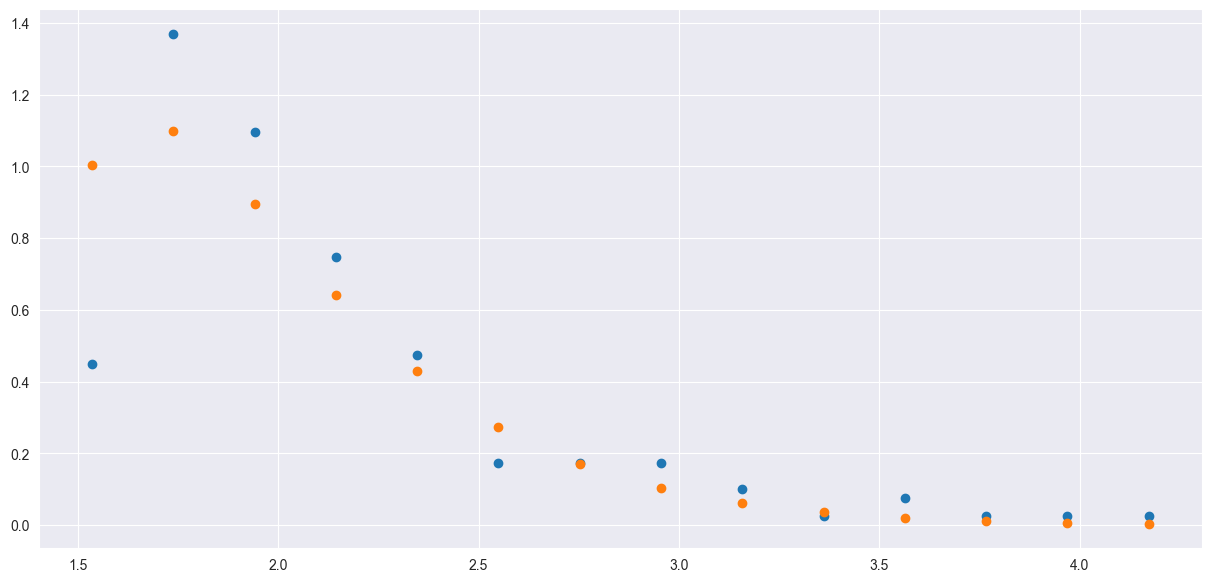

stats: 0.05125272016285541, p-value:0.6564161655969518


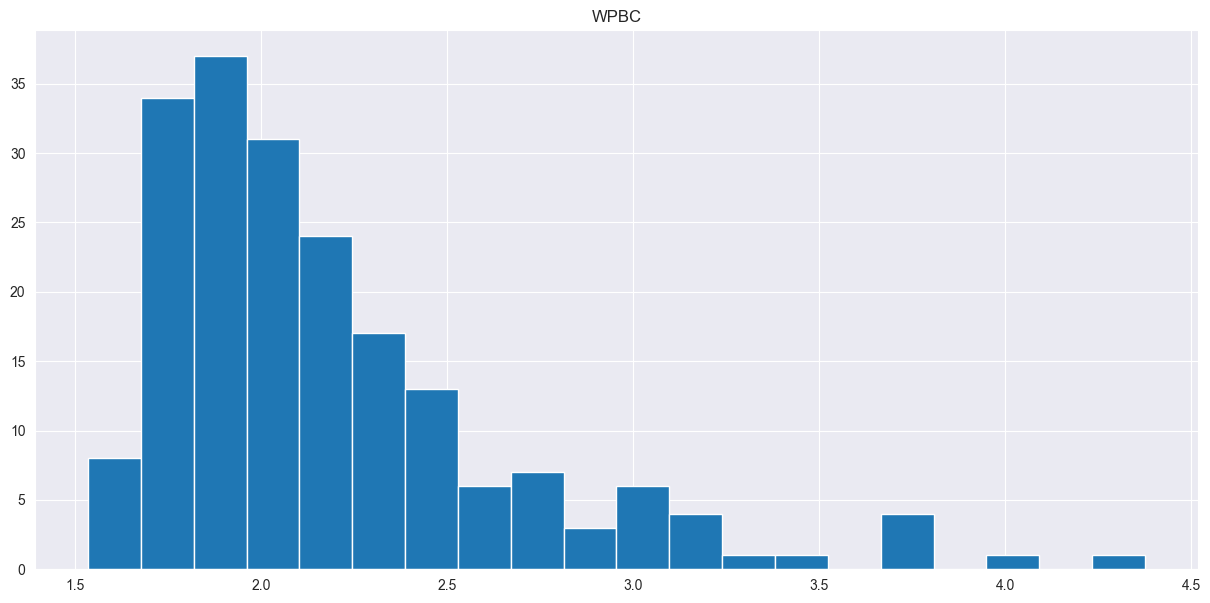

stats: 0.09676518976230974, p-value:0.04581983685300428
a: 2.123036221894032 Loc: 1.5210969333341966, Scale: 0.3123887312172093


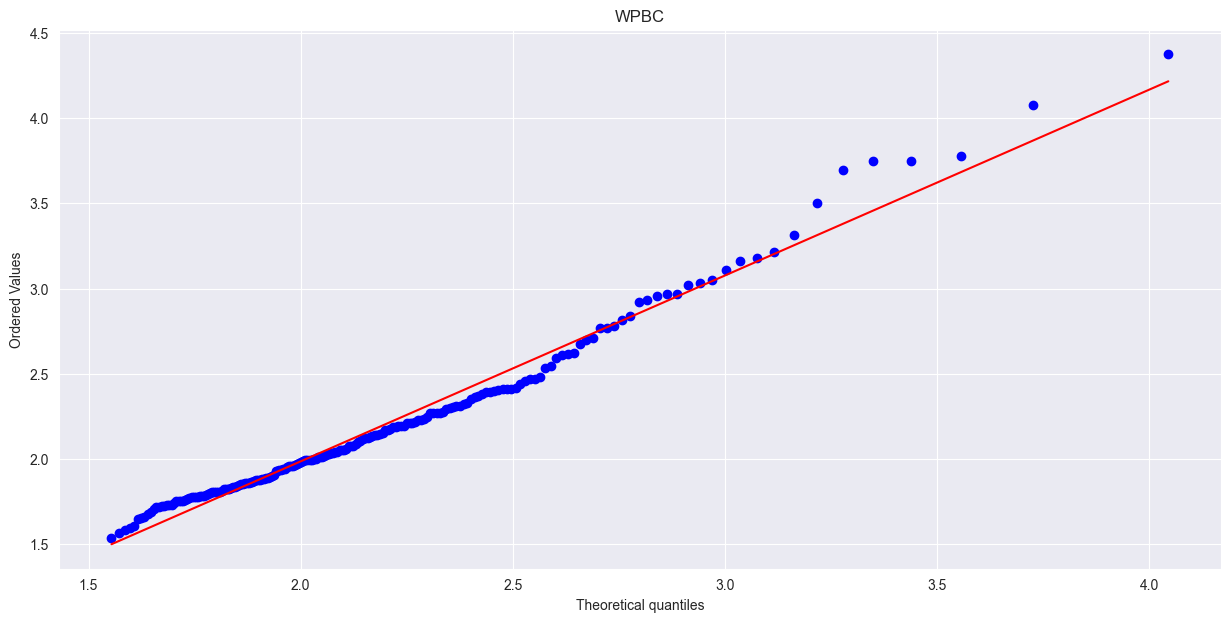

In [8]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 67)
ksTestArr(X,y,67,"WPBC")
ksTestNorm(X,y,67)
qqPlots(X,y,67,"WPBC")

0.6893382352941175 9 [0.37647058823529417, 0.6323529411764707, 0.6059027777777778, 0.6127450980392157, 0.6416666666666667, 0.5974264705882353, 0.6071428571428571, 0.6893382352941175, 0.6743697478991597, 0.6778846153846154, 0.6363636363636365, 0.6730769230769231, 0.6493506493506493, 0.6346153846153847, 0.5446428571428572, 0.5205128205128206, 0.4289772727272727, 0.484375, 0.4713541666666667, 0.41233766233766234, 0.34242424242424246, 0.4090909090909091, 0.46875, 0.6174242424242424, 0.6423611111111112, 0.5505952380952381, 0.49479166666666663, 0.5, 0.40374331550802145, 0.38181818181818183, 0.35795454545454547, 0.3787878787878788, 0.40584415584415584, 0.44047619047619047, 0.45238095238095233, 0.3928571428571429, 0.29545454545454547, 0.31493506493506496, 0.32867132867132876, 0.38141025641025644, 0.38141025641025644, 0.36309523809523814, 0.36011904761904767, 0.3571428571428571, 0.375, 0.39487179487179486, 0.39743589743589747, 0.44761904761904764, 0.44523809523809527, 0.484375, 0.42410714285714

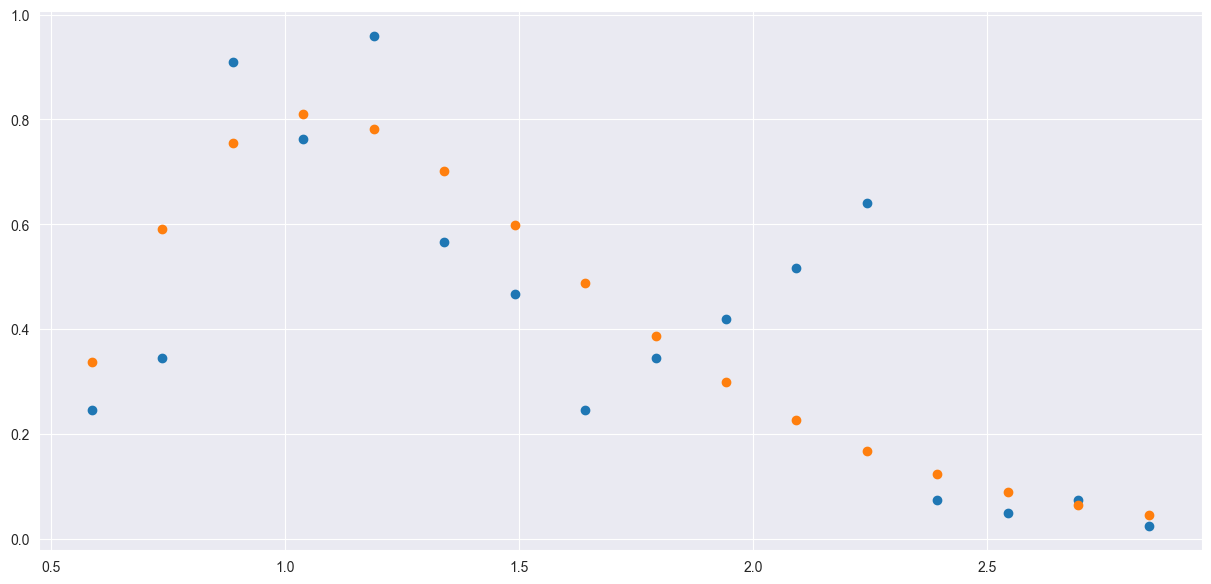

stats: 0.0868258752695017, p-value:0.032088845120162746


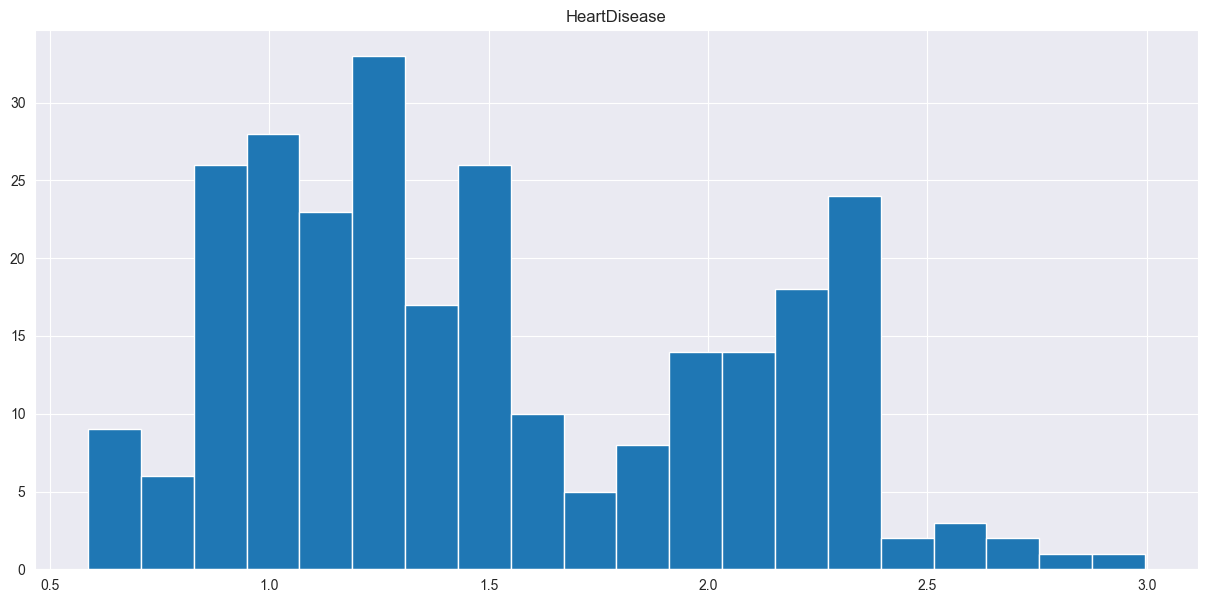

stats: 0.08282767536092073, p-value:0.04644844777605084
a: 3.474543528617488 Loc: 0.4566092437084571, Scale: 0.3025329167230343


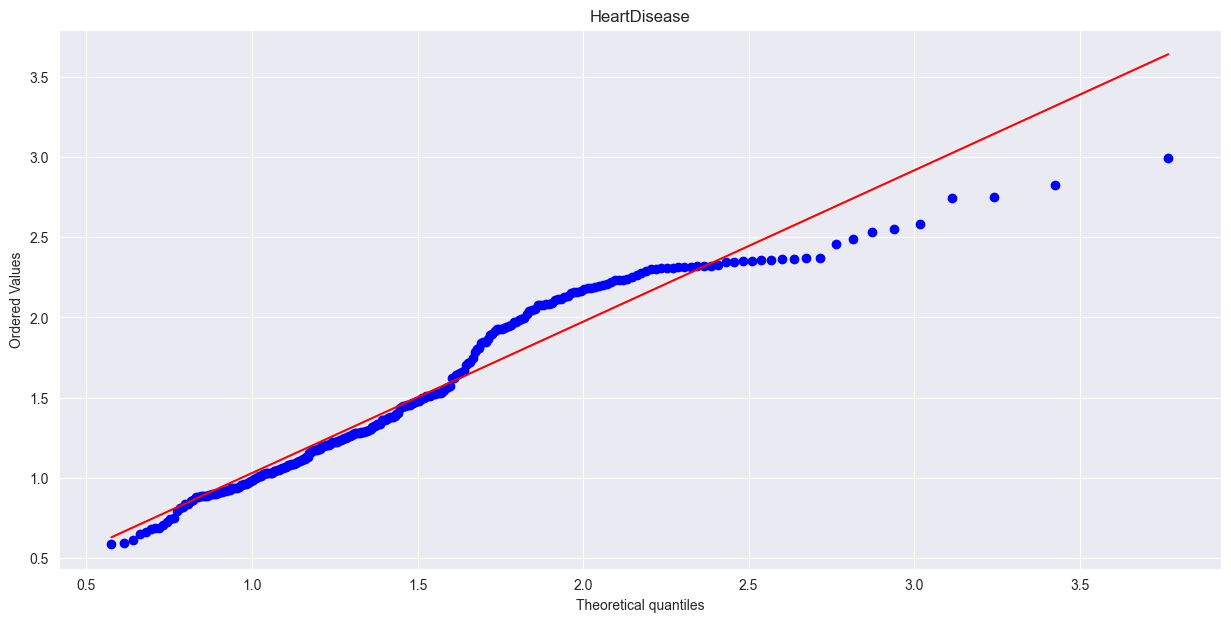

In [9]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 9)
ksTestArr(X,y,9,"HeartDisease")
ksTestNorm(X,y,9)
qqPlots(X,y,9,"HeartDisease")

0.8425925925925927 58 [0.33333333333333326, 0.38281249999999994, 0.3666666666666666, 0.5735294117647058, 0.5357142857142857, 0.6333333333333333, 0.6176470588235294, 0.631578947368421, 0.5555555555555556, 0.4444444444444444, 0.4444444444444444, 0.3777777777777778, 0.3666666666666667, 0.4027777777777778, 0.5098039215686274, 0.3666666666666667, 0.28205128205128205, 0.49999999999999994, 0.56140350877193, 0.5125, 0.3194444444444444, 0.6111111111111112, 0.5208333333333334, 0.5, 0.49999999999999994, 0.5208333333333333, 0.5614035087719298, 0.4333333333333333, 0.4705882352941176, 0.48148148148148134, 0.6499999999999999, 0.6406249999999999, 0.6166666666666665, 0.5104166666666666, 0.53125, 0.4903846153846154, 0.55, 0.6527777777777777, 0.4833333333333333, 0.42307692307692313, 0.4537037037037037, 0.5882352941176471, 0.671875, 0.59375, 0.4, 0.39743589743589747, 0.3782051282051282, 0.2642045454545454, 0.7749999999999999, 0.25, 0.6428571428571428, 0.31007751937984496, 0.3023255813953489, 0.29829545454

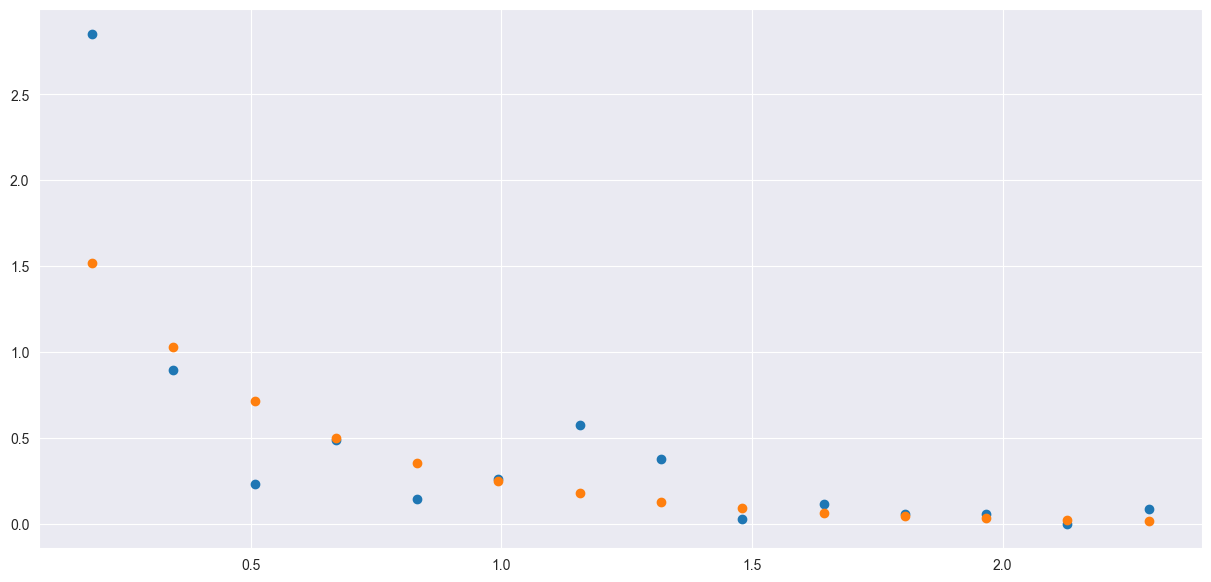

stats: 0.1645211287130528, p-value:1.5718645138752347e-05


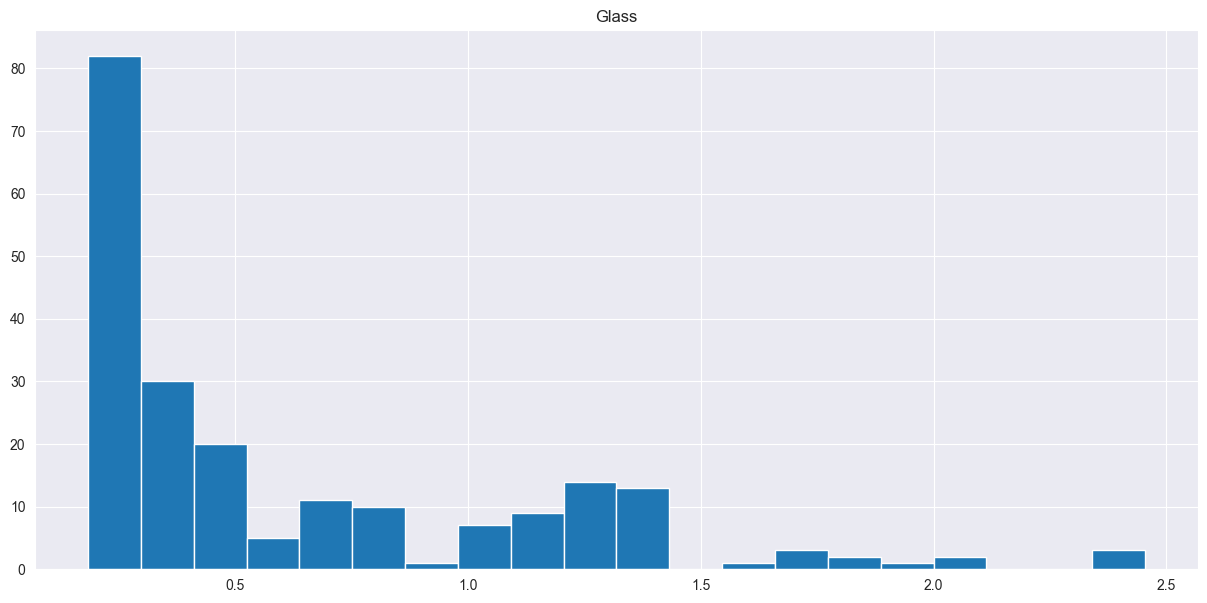

stats: 0.2895597132594918, p-value:2.2025760598009044e-16
a: 0.9124924830986287 Loc: 0.18328465883447376, Scale: 0.49386232456075196


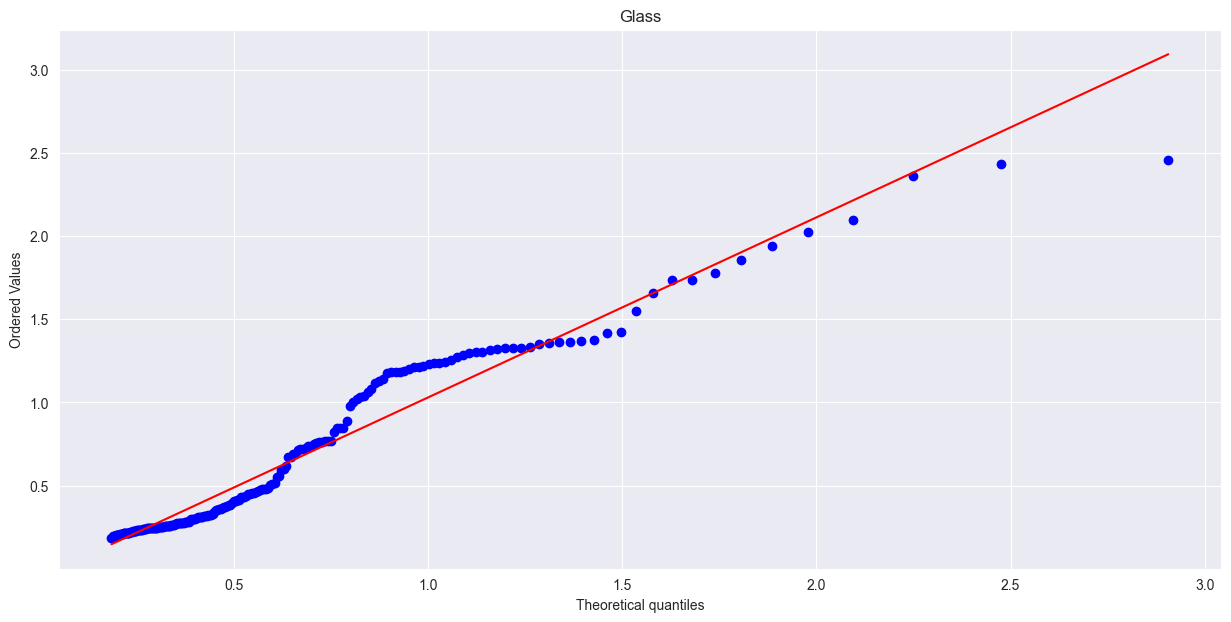

In [10]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 58)
ksTestArr(X,y,58,"Glass")
ksTestNorm(X,y,58)
qqPlots(X,y,58,"Glass")

0.6 58 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33333333333333326, 0.33333333333333326, 0.25, 0.2857142857142857, 0.2857142857142857, 0.16666666666666674, 0.08333333333333337, 0.16666666666666674, 0.16666666666666674, 0.3214285714285714, 0.4285714285714286, 0.4285714285714286, 0.39583333333333326, 0.45833333333333326, 0.47916666666666663, 0.30000000000000004, 0.0, 0.0, 0.25, 0.25, 0.375, 0.25, 0.4642857142857143, 0.4642857142857143, 0.4642857142857143, 0.4285714285714286, 0.4166666666666667, 0.375, 0.375, 0.2777777777777778, 0.49999999999999994, 0.42857142857142855, 0.49999999999999994, 0.5, 0.5, 0.6, 0.6, 0.3333333333333333, 0.30952380952380953, 0.3571428571428572, 0.40476190476190477, 0.38095238095238093, 0.4047619047619047, 0.45833333333333337, 0.43749999999999994, 0.38095238095238093, 0.3611111111111111]
0.4891918900253083
[1.13732964 0.99036103 0.73109445 0.50287709 0.33251273 0.21438425
 0.13581844 0.08494152]
0.9

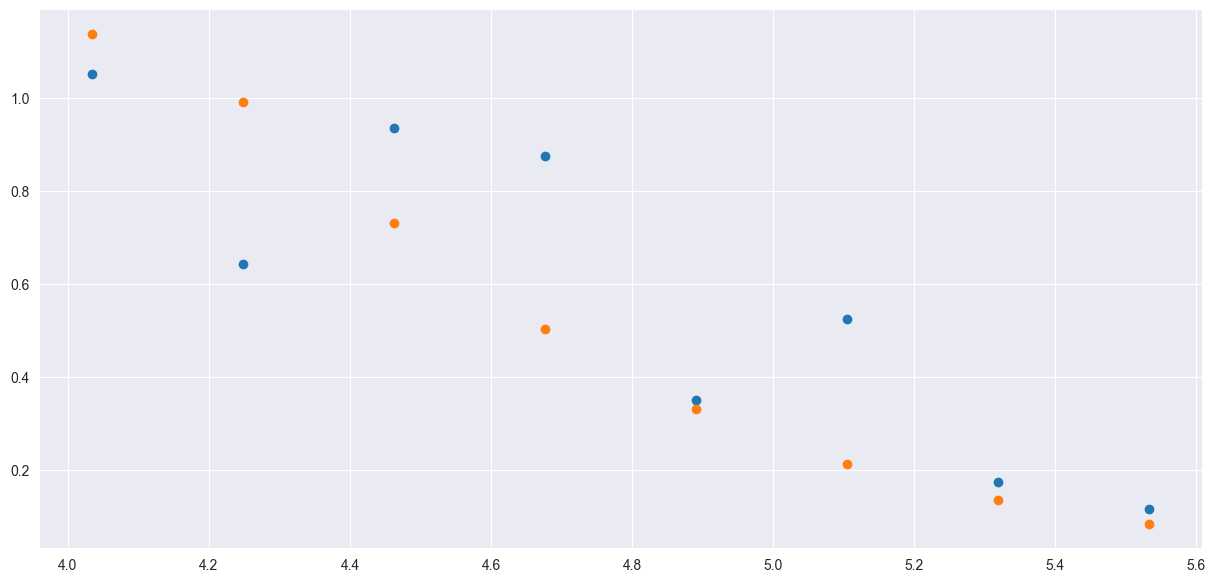

stats: 0.11460497411216086, p-value:0.22614059873817405


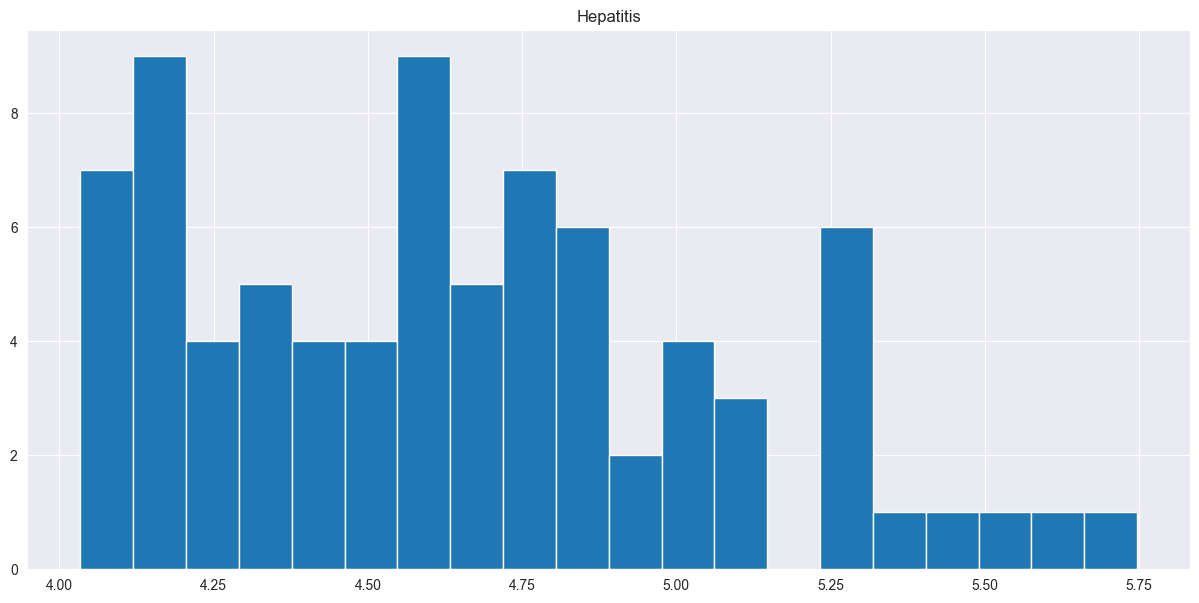

stats: 0.10404868773087939, p-value:0.32883809501091965
a: 1.644720975460336 Loc: 4.011838497887302, Scale: 0.38629004241705944


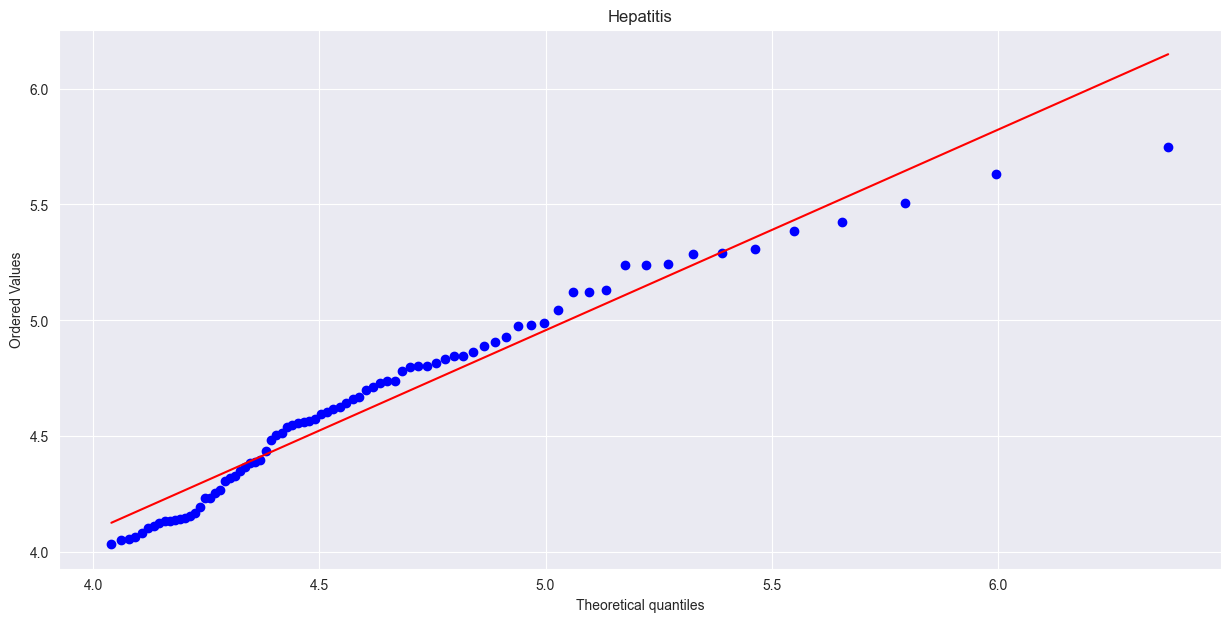

In [11]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 58)
ksTestArr(X,y,58,"Hepatitis")
ksTestNorm(X,y,58)
qqPlots(X,y,58,"Hepatitis")

0.5839947089947088 7 [0.2608695652173914, 0.3321428571428572, 0.4891428571428571, 0.5594444444444446, 0.5356321839080459, 0.5839947089947088, 0.5813793103448277, 0.563701923076923, 0.5296296296296295, 0.5328554360812425, 0.48263888888888884, 0.45794930875576034, 0.4718390804597701, 0.4212643678160918, 0.40555555555555545, 0.39179548156956, 0.3946236559139784, 0.38431590656284764, 0.36314655172413784, 0.3826473859844271, 0.35100446428571414, 0.3859375, 0.4166666666666667, 0.4455645161290323, 0.4599609375, 0.4408602150537635, 0.4236559139784946, 0.40722222222222215, 0.4466073414905451, 0.45297619047619037, 0.4559523809523809, 0.456547619047619, 0.4488095238095237, 0.4244444444444444, 0.42388888888888887, 0.41222222222222216, 0.41666666666666663, 0.4155555555555555, 0.4446236559139785, 0.4375650364203954, 0.40260416666666665, 0.4450604838709677, 0.4354838709677419, 0.40140086206896547, 0.387669801462905, 0.3949843260188088, 0.38133874239350907, 0.3847290640394089, 0.36916835699797157, 0.3

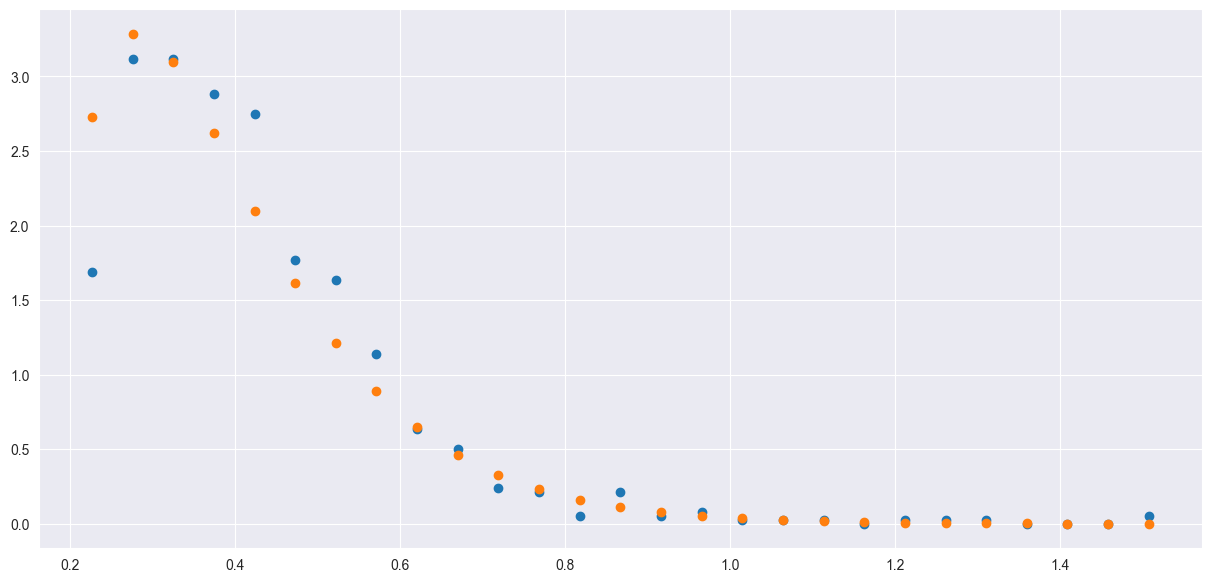

stats: 0.02246705111388425, p-value:0.8244349066578464


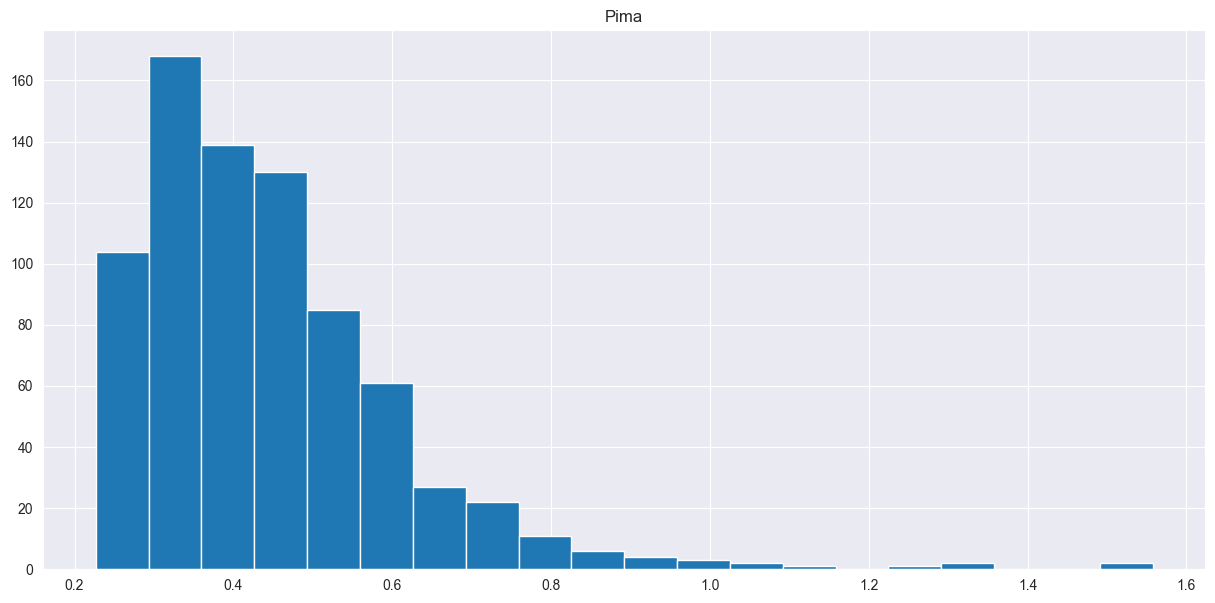

stats: 0.05658677171858939, p-value:0.0140510477665532
a: 1.954507485303796 Loc: 0.22194604553931097, Scale: 0.11401617427230512


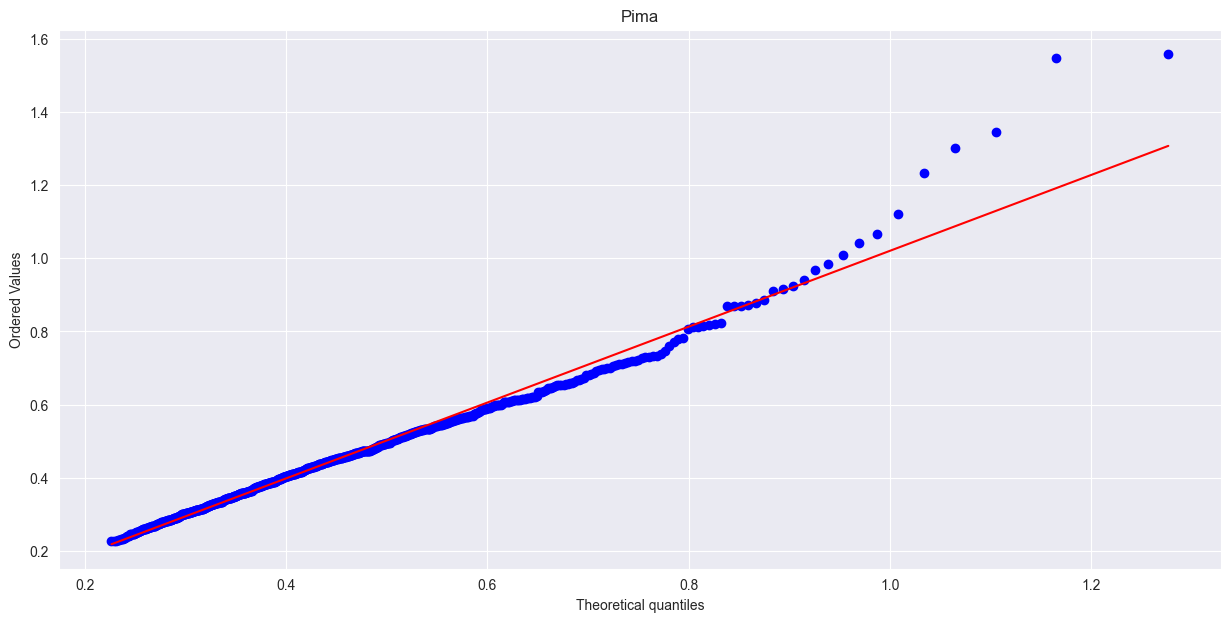

In [12]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 7)
ksTestArr(X,y,7,"Pima")
ksTestNorm(X,y,7)
qqPlots(X,y,7,"Pima")

0.9537767756482526 11 [0.7370443349753695, 0.6534229828850855, 0.8389751758927386, 0.8023529411764705, 0.8445475638051044, 0.9427745664739884, 0.9463276836158191, 0.9374307862679954, 0.9492509363295879, 0.9537767756482526, 0.9473830734966593, 0.9174008810572688, 0.9145742358078601, 0.9178610804851158, 0.888706140350877, 0.8940818584070797, 0.8654891304347825, 0.8653217011995636, 0.8687904967602591, 0.8686000716075903, 0.8952738990332975, 0.8640862495581477, 0.89026008492569, 0.8915421558164354, 0.8914021164021162, 0.9122105263157895, 0.8995824634655532, 0.9027979274611398, 0.8816390041493776, 0.8825726141078838, 0.8850311850311849, 0.8645768025078369, 0.8605263157894737, 0.8591858037578287, 0.8582635983263598, 0.8625922023182298, 0.8634453781512605, 0.8556494192185851, 0.8436903499469778, 0.8420274551214361, 0.8347734457323499, 0.8361904761904762, 0.8384371700105596, 0.841595744680851, 0.8334408602150538, 0.8260729613733905, 0.8185265438786565, 0.8106243154435925, 0.8143487858719647, 0

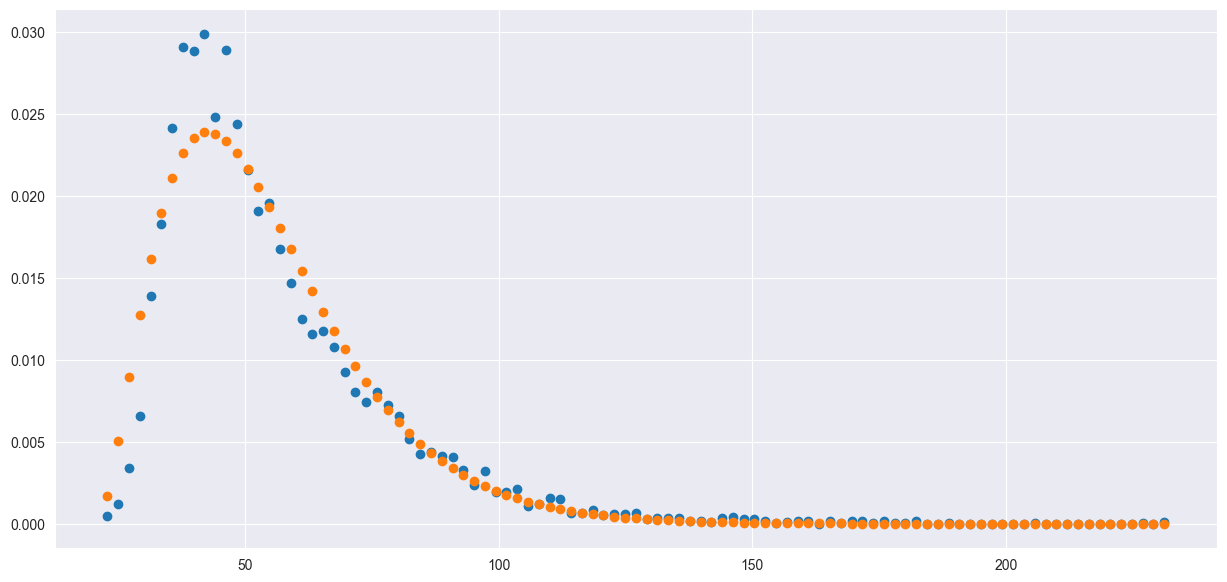

stats: 0.045332153303365263, p-value:4.637842064825321e-18


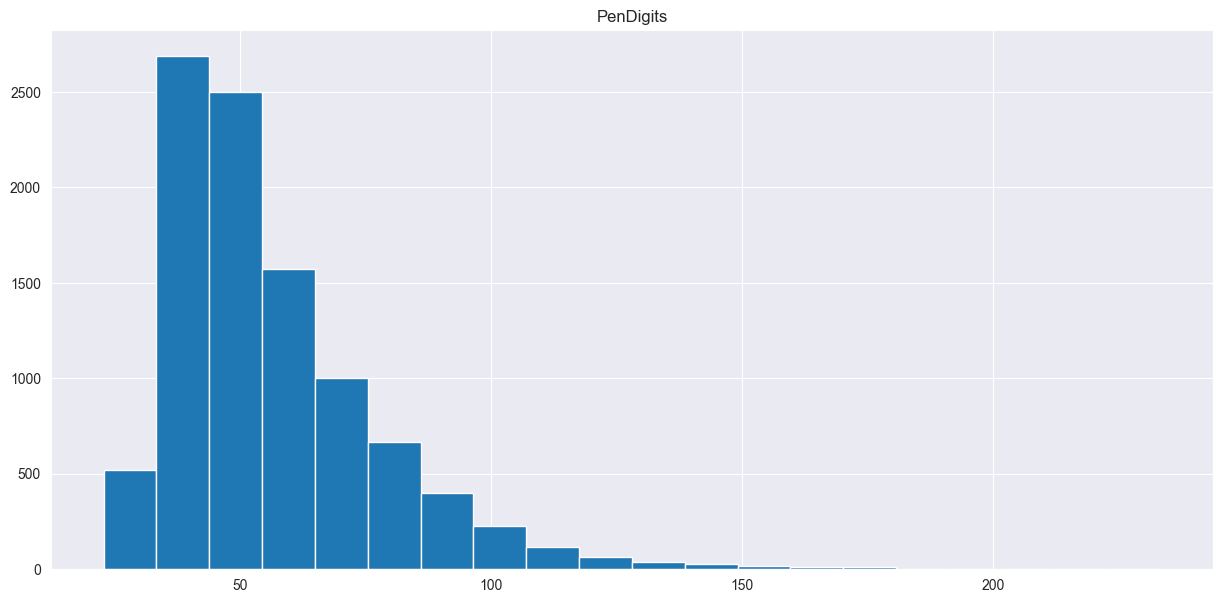

stats: 0.06724616294670316, p-value:3.0467514125256775e-39
a: 2.8905635382501305 Loc: 22.84356007722932, Scale: 11.619998021351272


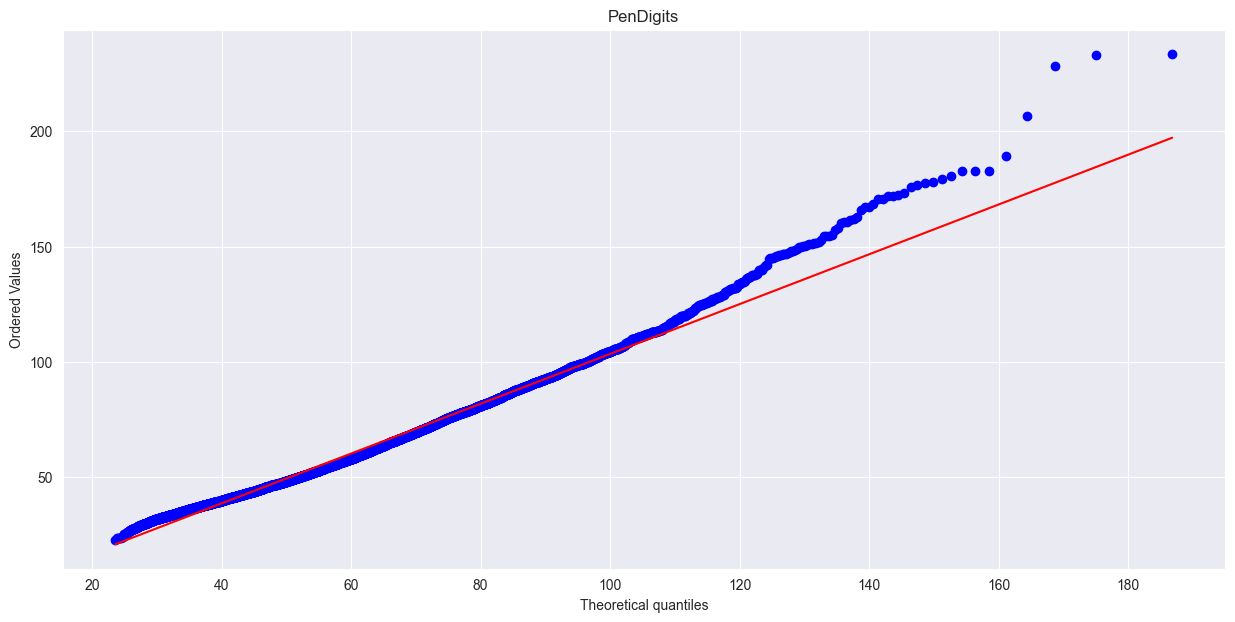

In [13]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 11)
ksTestArr(X,y,11,"PenDigits")
ksTestNorm(X,y,11)
qqPlots(X,y,11,"PenDigits")

1.0 32 [0.97, 0.7104798441115577, 0.6025805996472662, 0.6573103316812807, 0.5619667661180376, 0.7002101944298477, 0.8358859801938133, 0.6827667593450726, 0.7204865348629077, 0.8226468737565814, 0.8638075758597921, 0.8518177474699213, 0.8718123087385243, 0.7647400522799883, 0.8834382319991851, 0.7769500438212094, 0.6884422110552764, 0.8074186991869918, 0.5466101694915254, 0.8224247890227403, 0.628755364806867, 0.8362026862026862, 0.8179614706623017, 0.6325757575757576, 0.6902985074626866, 0.6696428571428571, 0.5950413223140494, 0.8240704243857574, 0.8044308357348702, 0.7937319884726224, 1.0, 0.8234938138784291, 1.0, 0.9667832167832169, 1.0, 1.0, 1.0, 1.0, 1.0, 0.814168247944339, 0.8095282841571134, 1.0, 0.7979773236282196, 1.0, 1.0, 0.7980132450331126, 0.8124406779661018, 0.8178694158075602, 0.8218641114982579, 0.8251119599578504, 0.8195866514979144, 0.8270345175107081, 0.830437480608129, 0.8088254338254337, 0.7967139398132134, 0.7970307167235494, 0.7998507361422078, 0.8047357351244995,

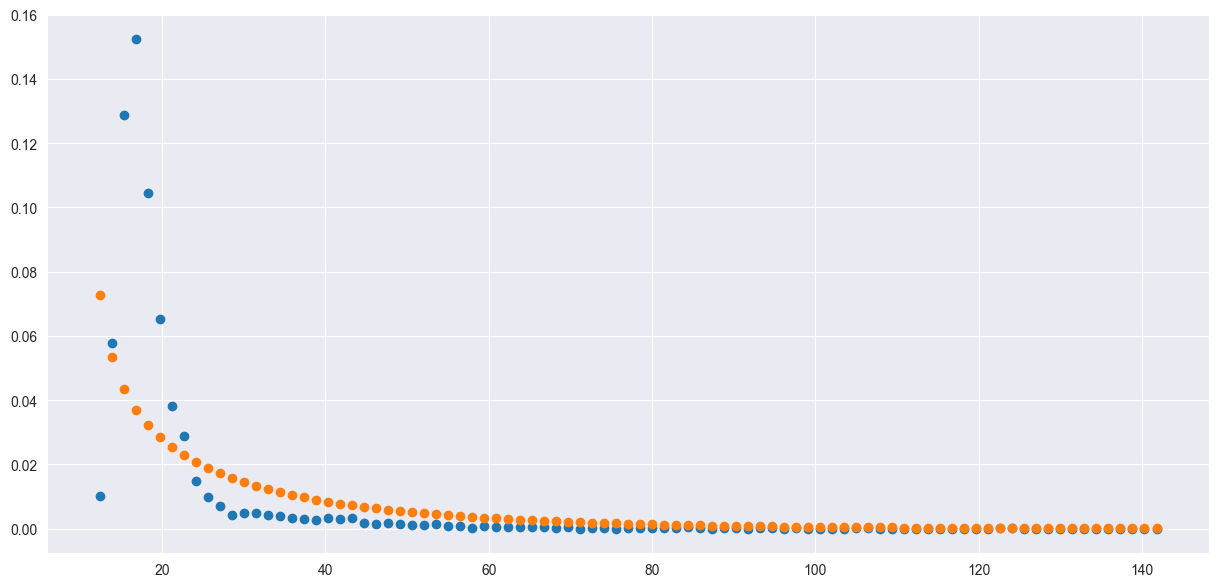

TypeError: ksTestArr() missing 1 required positional argument: 'name'

In [14]:
X, y = setupDf("clusters/artificial/cluto-t4-8k.arff")
endResults = outputResultsArt(X, y,checkValue=6)
printResults(endResults)
goodnessOfFit(X, y, 32)
ksTestArr(X,y,32)

1.0 41 [0.8308555033907146, 0.605069791914255, 0.7022513958050398, 0.6819318286081292, 0.684841326607439, 0.7795707035784484, 0.762487202974298, 0.7432697947214074, 0.7954800404935841, 0.8186159844054581, 0.8144599303135888, 0.8254994466771507, 0.8408230842005675, 0.8465894465894466, 0.8515439815566451, 0.8553107870514013, 0.8591691995947317, 0.873425160697888, 0.8667052245999615, 0.8555353901996369, 0.8524263950701816, 0.8542907261228825, 0.8615464994775339, 0.8573134064379202, 0.8589794653921046, 0.8551716597419639, 0.8386983082706768, 0.8361890552052751, 0.7725694444444446, 0.846517119244392, 0.8463990554899646, 0.8549705689993459, 0.8627536231884058, 0.8692286676987522, 0.8632554945054944, 0.8596367400715226, 0.8631279752276193, 0.8755922091595016, 0.8768080357142857, 1.0, 0.8776524741081703, 1.0, 1.0, 0.0, 0.8748018648018647, 0.0, 0.8697273418202546, 0.8634653018214663, 0.8736607142857143, 0.8612985925809657, 0.8590278130879136, 0.8670263788968825, 0.8560278639345095, 0.8572667891

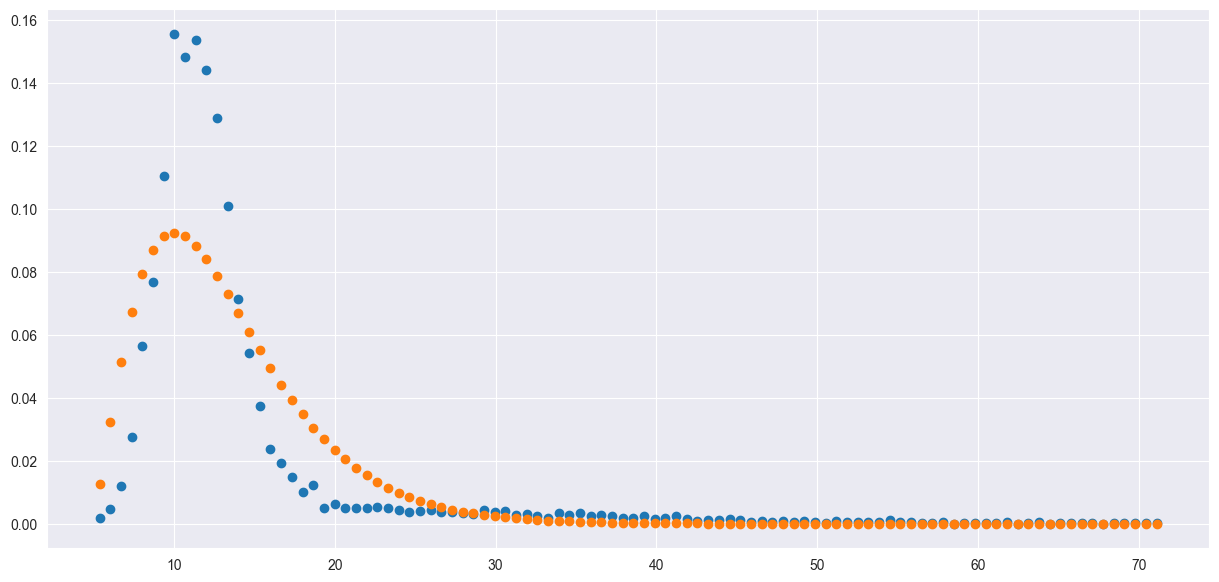

In [33]:
X, y = setupDf("clusters/artificial/cluto-t7-10k.arff")
endResults = outputResultsArt(X, y,checkValue=9)
printResults(endResults)
goodnessOfFit(X, y, 11)

1.0 20 [0.7959183673469387, 0.5325551615445234, 0.7730051480051479, 0.6921305001880402, 0.8155104241552835, 0.7928120063191143, 0.8244269722814499, 0.7777777777777776, 0.8106873997284957, 0.7672105672105671, 0.7848881740196079, 0.7570066865841513, 0.9327152330216445, 0.9390932352470814, 0.754138321995465, 0.7337159335067288, 0.7349422231311996, 0.7185400806090458, 1.0, 1.0, 0.7240022855133614, 0.700365120274914, 0.6994599807135969, 0.7045720770188153, 0.7241728820042074, 0.6885610766045547, 0.6902878835811451, 0.6785714285714287, 0.6591925258591925, 0.6975762153254599, 0.7028073412633037, 0.7041655655391119, 0.7029244170814776, 0.6906551059730249, 0.6805357142857142, 0.6827248549323016, 0.6845864212287832, 0.6830640423031729, 0.6781266216917489, 0.696048083372027, 0.6846112706187016, 0.696202699829932, 0.6890943877551022, 0.8110902255639099, 0.6971059361959889, 0.8848425196850394, 0.6687342964824122, 0.9009009009009008, 0.684677210267047, 0.6834190740007915, 0.6916320664324496, 0.68204

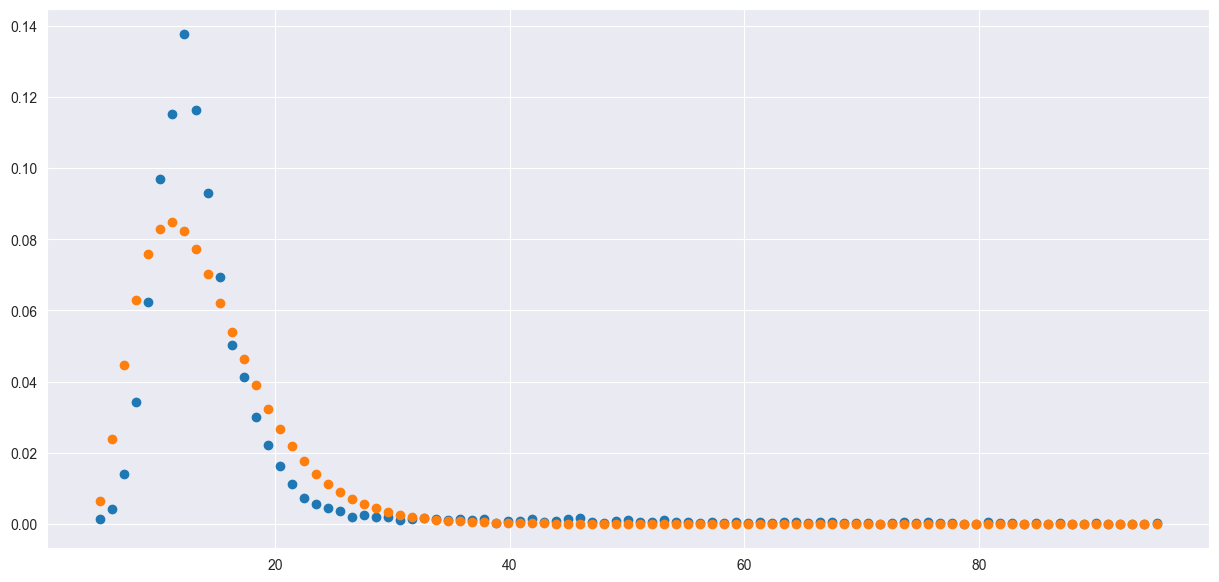

In [16]:
X, y = setupDf("clusters/artificial/cluto-t8-8k.arff")
endResults = outputResultsArt(X, y,checkValue=8)
printResults(endResults)
goodnessOfFit(X, y, 11)